# EvalRX: gemma-4-e2b on cruxeval_output (TPU)

[Open in Colab](https://colab.research.google.com/github/evalvitals/evalrx/blob/ruinan/examples/colab/tpu/code_reasoning_repair.ipynb)

Select a **TPU** runtime. This notebook launches **Antigravity CLI (`agy`) inside the runtime** for analysis and repair-code generation. Add `GEMINI_API_KEY` to Colab Secrets and allow notebook access (or enter it when asked). The API key drives the agent; the model under diagnosis runs locally on the accelerator.

We freeze 128 benchmark questions with seed 0, split them into 64 EXPLORE and 64 CONFIRM cases, select a repair using EXPLORE only, and evaluate the frozen winner once on CONFIRM. The model weights stay unchanged: L1 changes prompts and L2 changes the inference procedure. Agent-written code must pass the framework's frozen-model control; solving the task directly in Python does not count as repairing the model. A positive result must be established by the saved execution, not assumed from the notebook title.


## 1. Install

EvalRX runs in its own environment: a Python 3.12 interpreter and the exact package versions in `tools/colab/lock/tpu.txt`, installed to `/content/evalrx-env`. The notebook kernel's Python is left unchanged, so this cell gives the same environment on an updated Colab image or a Google-internal Colab runtime. Setup checks the network endpoints it needs first and names the variable that redirects any blocked one. Where GitHub or PyPI are unreachable, set `EVALRX_BUNDLE` to an offline bundle built with `tools/colab/build_bundle.sh`; see [the Colab README](https://github.com/evalvitals/evalrx/blob/ruinan/examples/colab/README.md).

In [1]:
import os, subprocess, sys, json, shutil, tarfile, tempfile, urllib.request
from pathlib import Path
ACCEL = 'tpu'
# Pinned source revision. Change only to run newer EvalRX code.
EVALRX_REF = os.environ.get('EVALRX_REF', '63933a297316f6cbd72f1c15153b5bc3a200afb6')
# Offline bundle from tools/colab/build_bundle.sh: a local path (e.g. on Drive), https:// or gs:// URL.
# Set it where GitHub/PyPI are unreachable; then nothing else is downloaded during setup.
EVALRX_BUNDLE = os.environ.get('EVALRX_BUNDLE', '')
# Model weights from tools/colab/build_weights.sh (a .tar, same locations), or a directory with them.
# Set it where gs://gemma-data is unreachable; the run cell then loads the model from it.
EVALRX_WEIGHTS = os.environ.get('EVALRX_WEIGHTS', '')
base = Path('/content') if Path('/content').is_dir() else Path.home()
repo = Path(os.environ.get('EVALRX_REPO', base / 'evalrx'))
env = Path(os.environ.setdefault('EVALRX_ENV', str(base / 'evalrx-env')))
os.environ.setdefault('EVALRX_DEMO_ROOT', str(base / 'evalrx_examples'))
os.environ.update(OMP_NUM_THREADS='2', PYTHONUNBUFFERED='1', TF_CPP_MIN_LOG_LEVEL='2',
                  MALLOC_ARENA_MAX='2', MALLOC_TRIM_THRESHOLD_='0')
def run_visible(command):
    with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end='', flush=True)
        if process.wait():
            raise subprocess.CalledProcessError(process.returncode, command)
def unpack_tar(source, dest):
    """Download (gs://, https://) or open (local path) a .tar and unpack its one top directory to dest."""
    scratch = Path(tempfile.mkdtemp(dir=dest.parent))
    if source.startswith(('gs://', 'http://', 'https://')):
        local = str(scratch / Path(source).name)
        if source.startswith('gs://') and (shutil.which('gcloud') or shutil.which('gsutil')):
            tool = ['gcloud', 'storage', 'cp'] if shutil.which('gcloud') else ['gsutil', 'cp']
            run_visible(tool + [source, local])
        elif source.startswith('gs://'):  # no Cloud SDK, e.g. Colab TPU runtimes
            from google.cloud import storage
            bucket, _, name = source[len('gs://'):].partition('/')
            try:  # your credentials (google.colab.auth.authenticate_user()) ...
                client = storage.Client(project=os.environ.get('GOOGLE_CLOUD_PROJECT', '_'))
                client.bucket(bucket).blob(name).download_to_filename(local)
            except Exception:  # ... else anonymous, for a public bucket
                client = storage.Client.create_anonymous_client()
                client.bucket(bucket).blob(name).download_to_filename(local)
        else:
            urllib.request.urlretrieve(source, local)
        source = local
    with tarfile.open(source) as archive:
        archive.extractall(scratch / 'unpacked', **({'filter': 'data'} if hasattr(tarfile, 'data_filter') else {}))
    (top,) = (scratch / 'unpacked').iterdir()
    top.rename(dest)
    shutil.rmtree(scratch)
if not repo.exists() and EVALRX_BUNDLE:
    unpack_tar(EVALRX_BUNDLE, repo)
elif not repo.exists():
    if not shutil.which('git'):
        raise RuntimeError('git is not installed on this runtime: set EVALRX_BUNDLE to an offline bundle '
                           '(tools/colab/build_bundle.sh); it needs neither git nor package downloads.')
    run_visible(['git', 'init', '-q', str(repo)])
    run_visible(['git', '-C', str(repo), 'fetch', '-q', '--depth', '1',
                 'https://github.com/evalvitals/evalrx.git', EVALRX_REF])
    run_visible(['git', '-C', str(repo), 'checkout', '-q', 'FETCH_HEAD'])
# EvalRX gets its own Python 3.12 and locked packages in EVALRX_ENV; this kernel's
# Python is not modified, so Colab image updates do not change the environment.
run_visible(['bash', str(repo / 'tools/colab/bootstrap.sh'), ACCEL])
if (repo / '.bundle/data').is_dir():  # datasets frozen into the bundle
    shutil.copytree(repo / '.bundle/data', Path(os.environ['EVALRX_DEMO_ROOT']) / 'data', dirs_exist_ok=True)
if EVALRX_WEIGHTS:
    weights = Path(EVALRX_WEIGHTS)
    if not weights.is_dir():
        weights = base / 'evalrx-weights'
        if not weights.exists():
            unpack_tar(EVALRX_WEIGHTS, weights)
            run_visible(['bash', '-c', f'cd {weights} && sha256sum --quiet -c SHA256SUMS && echo weights verified'])
    os.environ['EVALRX_MODEL_PATH'] = str(weights)  # the run cell passes it as --model-path
os.environ['PATH'] = f"{env / 'bin'}:{os.environ['PATH']}"
os.chdir(repo)


[evalrx-bootstrap] reachable  https://pypi.org/simple/pip/


[evalrx-bootstrap] reachable  https://download.pytorch.org/whl/cpu/torch/


[evalrx-bootstrap] reachable  https://github.com/astral-sh/python-build-standalone/releases/download


[evalrx-bootstrap] reachable  https://antigravity.google/cli/install.sh


[evalrx-bootstrap] Python: /content/evalrx-env/.python/cpython-3.12-linux-x86_64-gnu/bin/python3.12


[evalrx-bootstrap] versions {'evalrx': '0.1.2', 'jax': '0.7.2', 'libtpu': '0.0.21.1', 'gemma': '4.0.1', 'flax': '0.11.2', 'torch': '2.9.0+cpu'} python 3.12.15


[evalrx-bootstrap] ready: /content/evalrx-env/bin (python, evalrx, agy)


## 2. Verify the TPU and launch agy

The agent must create and execute a Python file before the benchmark starts. Its transcript stays in this notebook.

In [2]:
run_visible([str(env / 'bin/python'), '-c', "import jax; assert jax.default_backend() == 'tpu'; print([(str(d), d.device_kind) for d in jax.devices()])"])
commit = repo / '.bundle/COMMIT'
git_head = (subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=repo, capture_output=True, text=True)
            if shutil.which('git') and not commit.exists() else None)
print('Source revision:', commit.read_text().strip() if commit.exists() else
      git_head.stdout.strip() if git_head and git_head.returncode == 0 else 'unknown (no git metadata)')
print('Runtime:', os.environ.get('COLAB_RELEASE_TAG', 'non-Colab validation environment'))
if not os.environ.get('GEMINI_API_KEY'):
    try:
        from google.colab import userdata
        os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
    except Exception:
        import getpass
        os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API key: ')
assert os.environ['GEMINI_API_KEY']
agent_dir = Path(os.environ['EVALRX_DEMO_ROOT']) / 'agent_check'
# The agent runs from the EvalRX environment, like every later EvalRX step.
run_visible([str(env / 'bin/python'), '-c', f"""
from pathlib import Path
from evalrx.agent_runtime.providers.antigravity import AntigravityAgent
agent_dir = Path({str(agent_dir)!r})
agent = AntigravityAgent(binary_path={str(env / 'bin/agy')!r}, model='gemini-3.8-flash-low',
                         timeout_sec=180, extra_args=['--output-format', 'stream-json'])
result = agent.run('Create agent_check.py that prints AGENT_READY. Run it with Python and report its output. Work only in this directory.', agent_dir)
print('Agent:', result.provider_name)
print(result.raw_output)
assert not result.error, result.error
assert (agent_dir / 'agent_check.py').exists()
print((agent_dir / 'agent_check.py').read_text())
"""])
run_visible([str(env / 'bin/python'), str(agent_dir / 'agent_check.py')])


/content/evalrx-env/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")


  warnings.warn(


[('TPU_0(process=0,(0,0,0,0))', 'TPU v5 lite')]


Source revision: acd49b4a44c217a1ada54726c4cda3af9860d441
Runtime: release-colab-external-images_20261008-060111_RC00


Agent: antigravity


...

{"event":"step_update","step_update":{"conversation_id":"4fe05c0c-2c27-4f18-a22b-fa69fbf77eea","step_index":3,"state":"DONE","step_type":"agent_response","duration_seconds":2.330949791,"usage":{"input_tokens":12718,"output_tokens":73,"thinking_tokens":0,"cache_read_tokens":0,"total_tokens":12791}}}


{"event":"step_update","step_update":{"conversation_id":"4fe05c0c-2c27-4f18-a22b-fa69fbf77eea","step_index":4,"state":"ACTIVE","step_type":"tool","tool_name":"run_command","tool_info":{"name":"run_command","parameters":{"CommandLine":"python3 agent_check.py"}}}}


{"event":"step_upd


print("AGENT_READY")


AGENT_READY


## 3. Run the complete EvalRX workflow

The command runs baseline evaluation, M1 probes, agent-written exploratory analysis, M2 statistics, M3 hypotheses, M4 tests and M5 repair search. `--skip-surgery` omits the separate surgery experiments; M5 repair still runs. Eight EXPLORE cases per analyzer bound the demonstration's probing cost; all 128 cases receive baseline evaluation, and all 64 CONFIRM cases are reserved for the frozen candidate.

The same 512-token generation budget applies to the baseline; repairs may request more tokens and their extra computation is recorded. This is an inference-repair demonstration, not a claim that the underlying weights improved.


In [3]:
%%bash
set -euo pipefail
"$EVALRX_ENV/bin/evalrx" run \
  --modality llm --model gemma-4-e2b --dataset cruxeval_output \
  --backend jax_local --device tpu --dtype bfloat16 \
  --limit 128 --download-limit 128 --seed 0 \
  --max-new-tokens 512 --temperature 0 --analyzer-max-cases 8 \
  --judge-provider agy --judge-model gemini-3.8-flash-low \
  --fix-tier L2 --fix-repair-rounds 2 --fix-validation-cases 64 \
  --allow-codegen --explore --m2-codegen --skip-surgery \
  --data-dir "$EVALRX_DEMO_ROOT/data" --run-dir "$EVALRX_DEMO_ROOT/runs" \
  --run-tag tpu_notebook \
  ${EVALRX_MODEL_PATH:+--model-path "$EVALRX_MODEL_PATH"}


[data] freezing cruxeval_output: limit=128 seed=0 val_limit=128 -> /content/evalrx_examples/data/cruxeval_output
[data] {"kept": 128, "slice_items": 800, "is_census": false, "fetch": "datasets-server", "manifest": "/content/evalrx_examples/data/cruxeval_output/manifest.json", "kept_val": 128, "manifest_val": "/content/evalrx_examples/data/cruxeval_output/manifest_val.json"}
[model] Gemma 4 E2B-it, spec gemma-4-e2b-it = google/gemma-4-E2B-it; backend=jax_local; benchmark=cruxeval_output; n=128
judge: agy model=gemini-3.8-flash-low effort=high
[model] weights loaded in 56s (attn_impl=None); generation={'max_new_tokens': 512, 'do_sample': False}
[device] tpu: TPU_0(process=0,(0,0,0,0)) (TPU v5 lite)
Baseline: PASS=63, FAIL=65, UNKNOWN=0, accuracy=0.492 (630s, 4.9s/case)

VLDiagnoseLoop  model=gemma-4-e2b  max_cycles=1
RUN loop        ·········· starting · model=JaxLocalModel(key='gemma-4-e2b-it', adapter=GemmaJaxAdapter, loaded) · n_cases=64
M1  probe       ········· cycle 0 · 8 analyzers

/content/evalrx-env/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
E1009 21:58:22.659700    7149 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/content/.config/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login
/content/evalrx-env/.python/cpython-3.12.15-linux-x86_64-gnu/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
 

## 4. Read the measured result

The benchmark uses its registered exact-answer grader. EXPLORE chooses the candidate; only an independent CONFIRM result can establish a successful repair.

Baseline: 63/128 (49.2%)
Verified hypotheses: 0
Frozen candidate: scratchpad_and_expanded_limit


,split,n,baseline_correct,candidate_correct,repaired_cases,regressed_cases,e_value,required_e_value,verdict,validated_fix
0,CONFIRM,64,32,41,9,0,51.2,20.0,fixed,True


<IPython.core.display.JSON object>

Accuracy repair validated.


### EXPLORE candidates (selection only)

,name,headline,tier,n_pairs,n_fixed,n_broken,effect,e_value,coverage,verdict
0,expanded_token_budget,Gives the model twice as much output space so ...,L1,0,0,0,NaN,NaN,0.0,not_executed
1,concise_state_trace,Directs the model to write only a brief line-b...,L1,64,7,5,0.031250,0.397824,1.0,partial
2,scratchpad_and_expanded_limit,Tells the model to double-check its work in a ...,L1,64,17,2,0.234375,153.300585,1.0,fixed


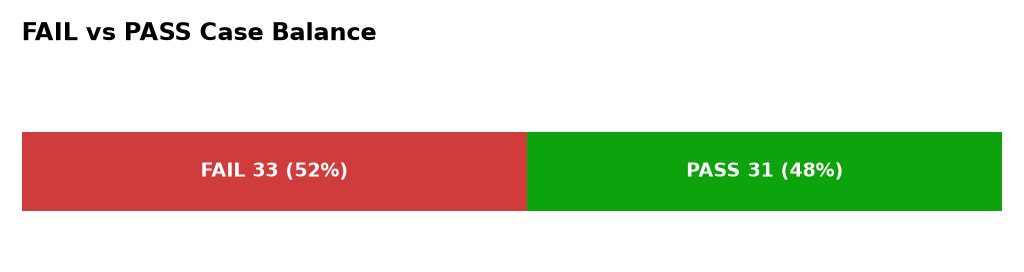

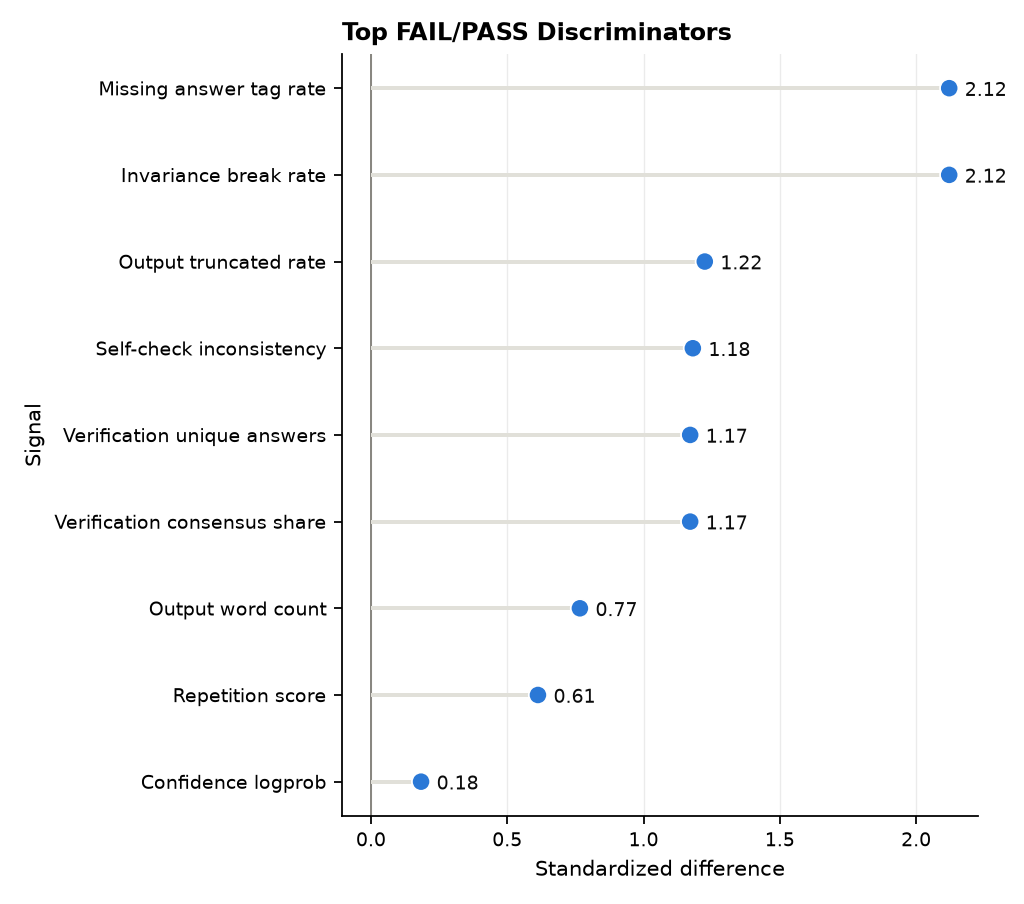

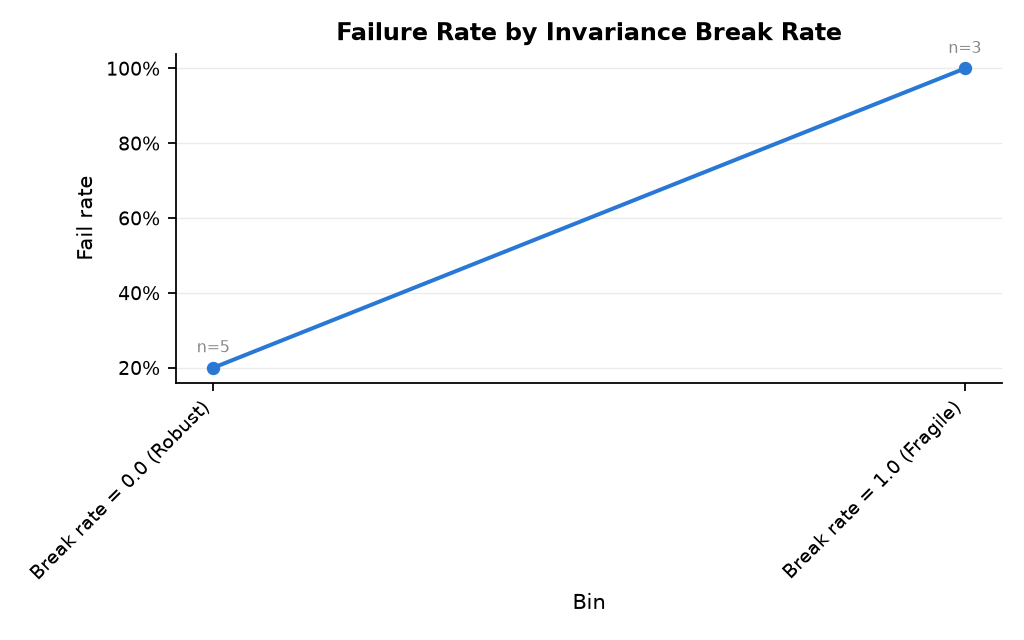

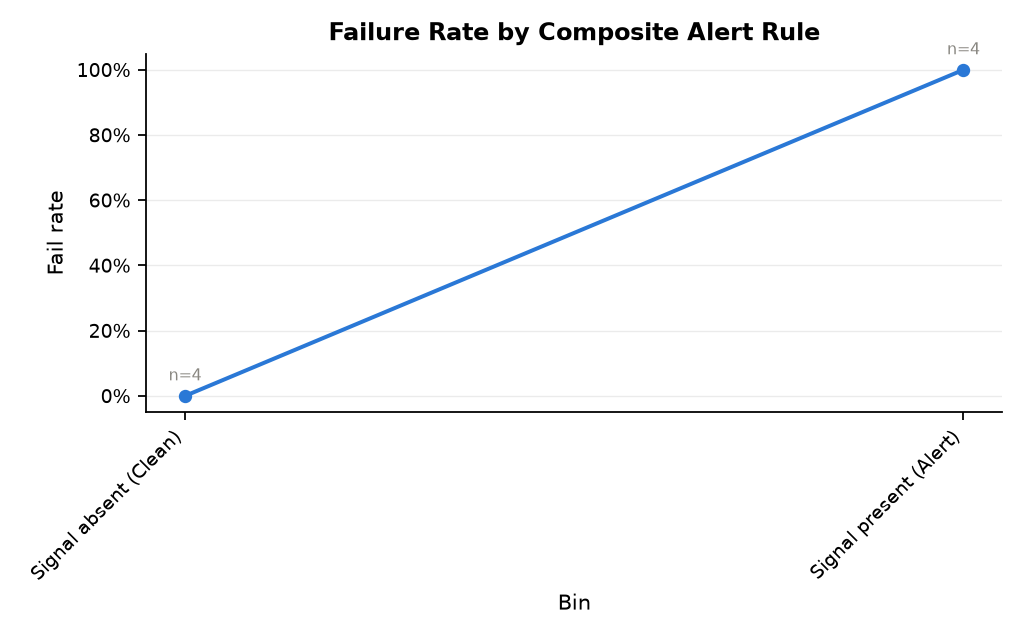

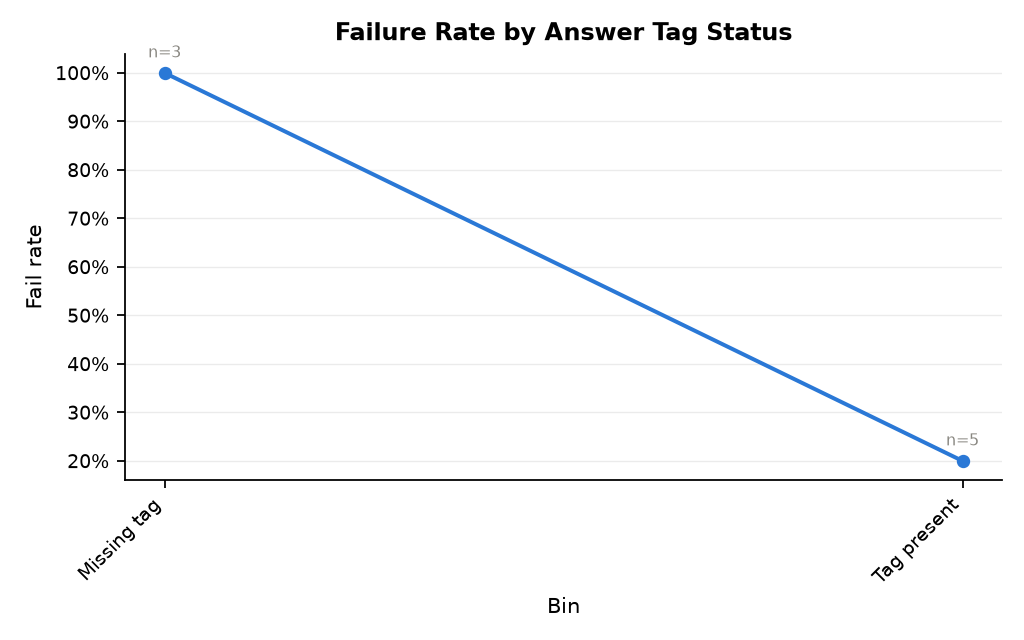

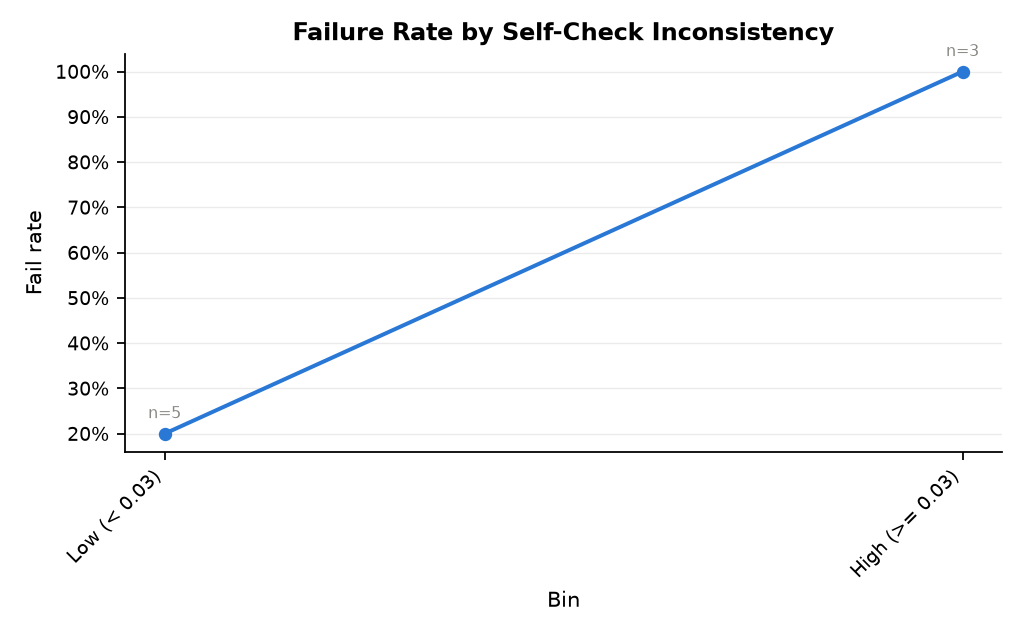

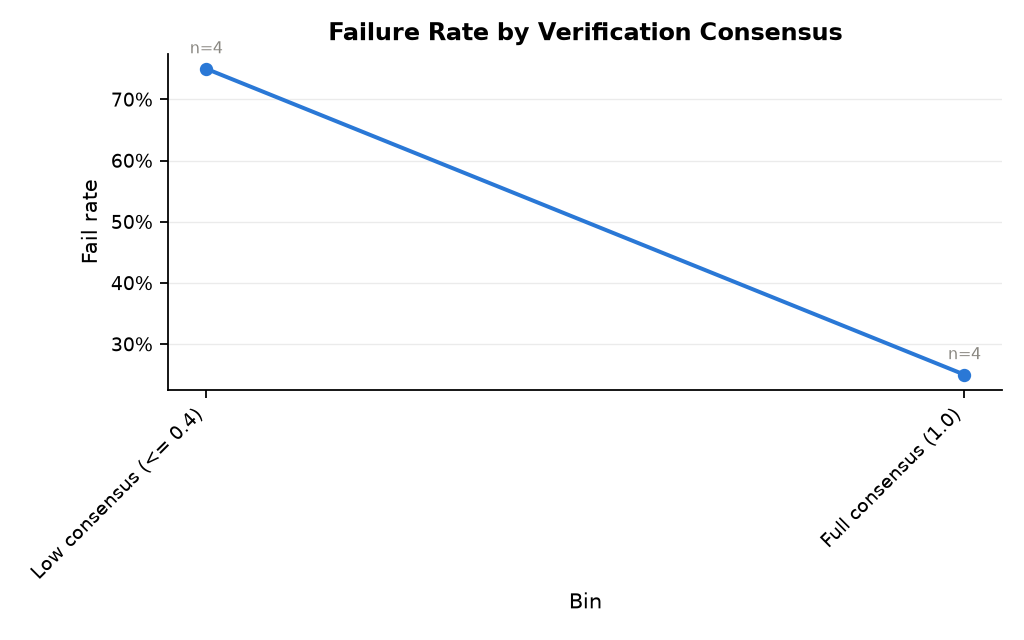

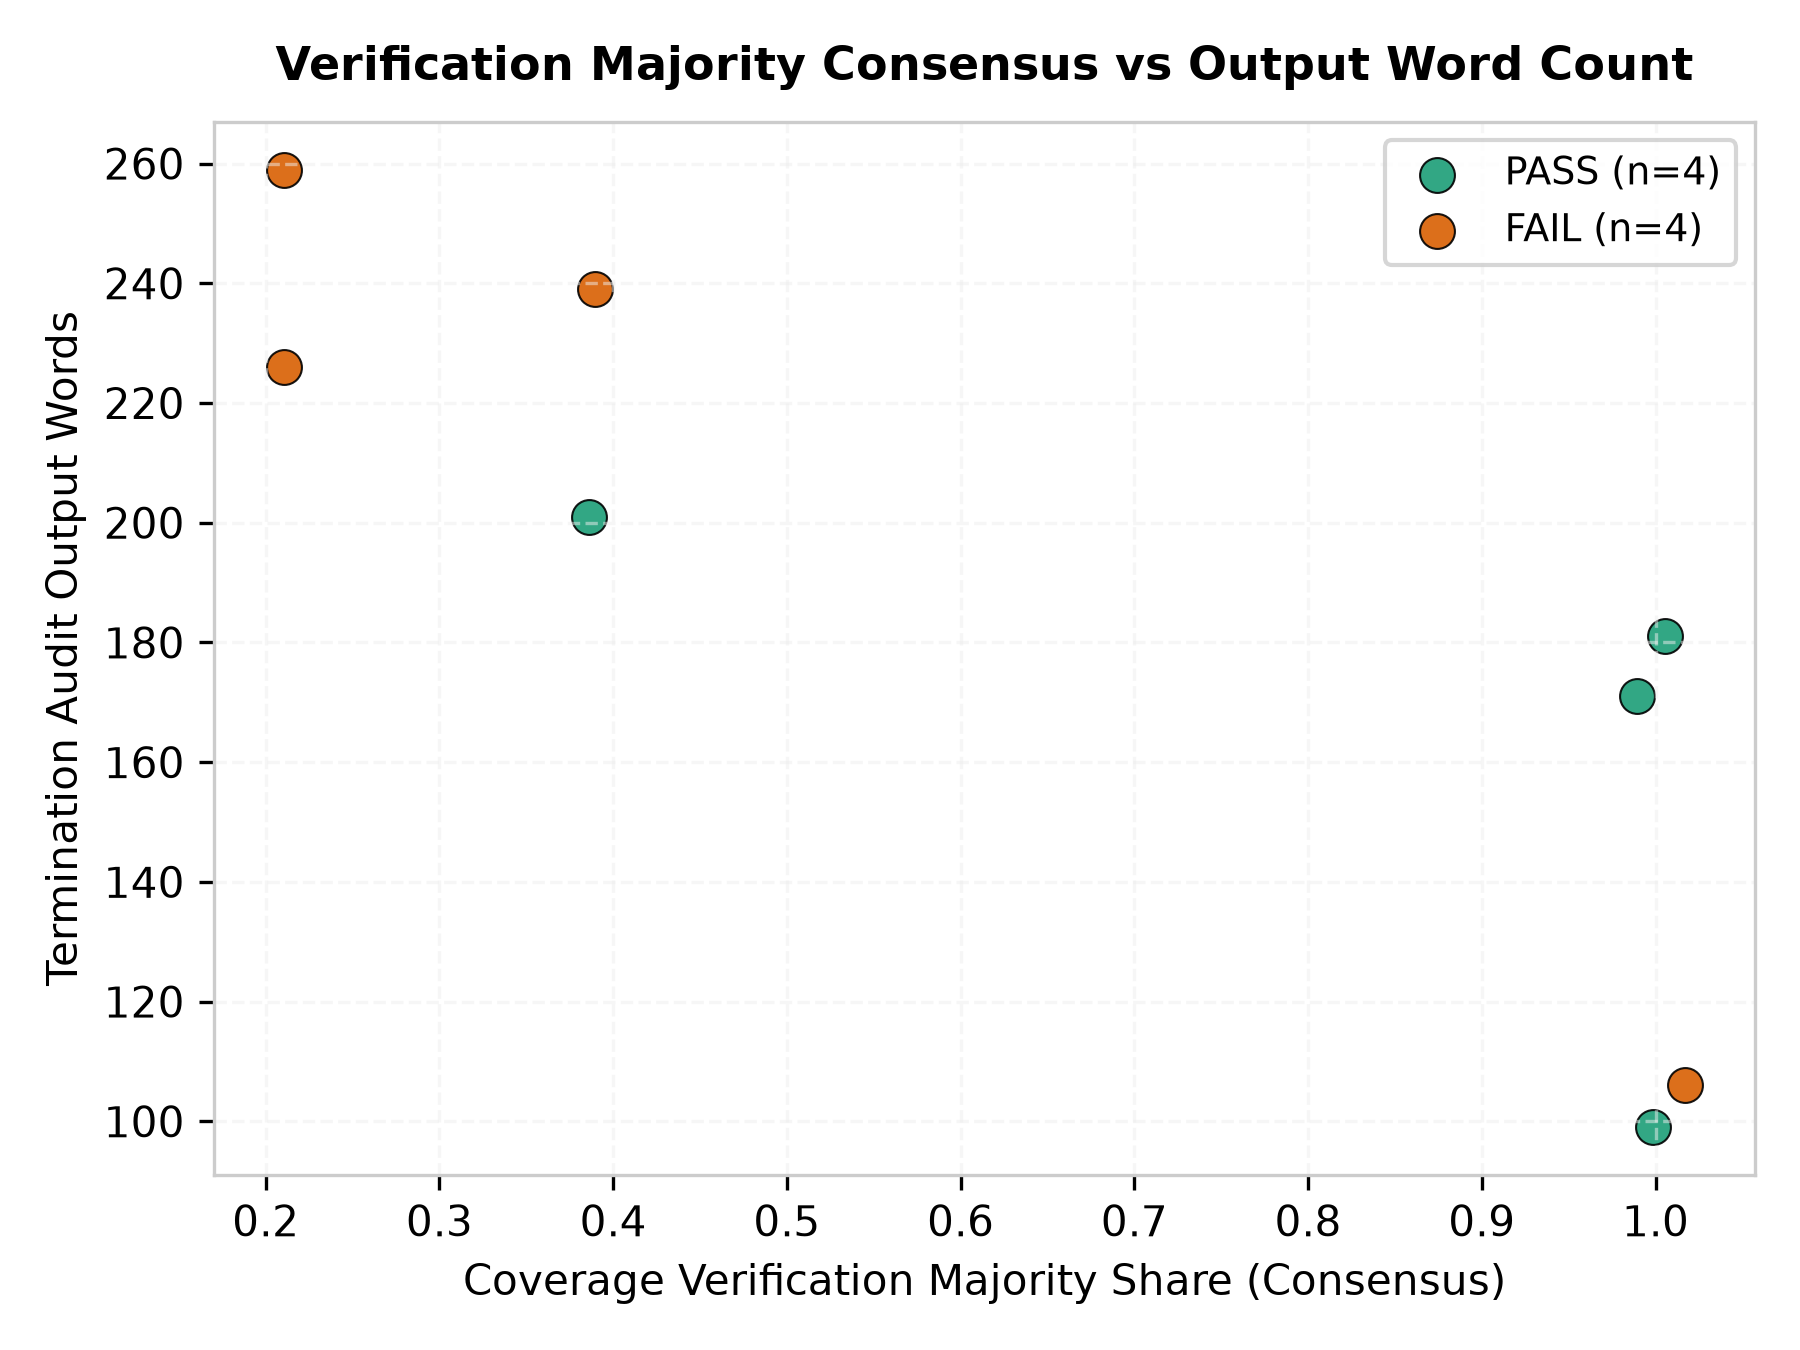

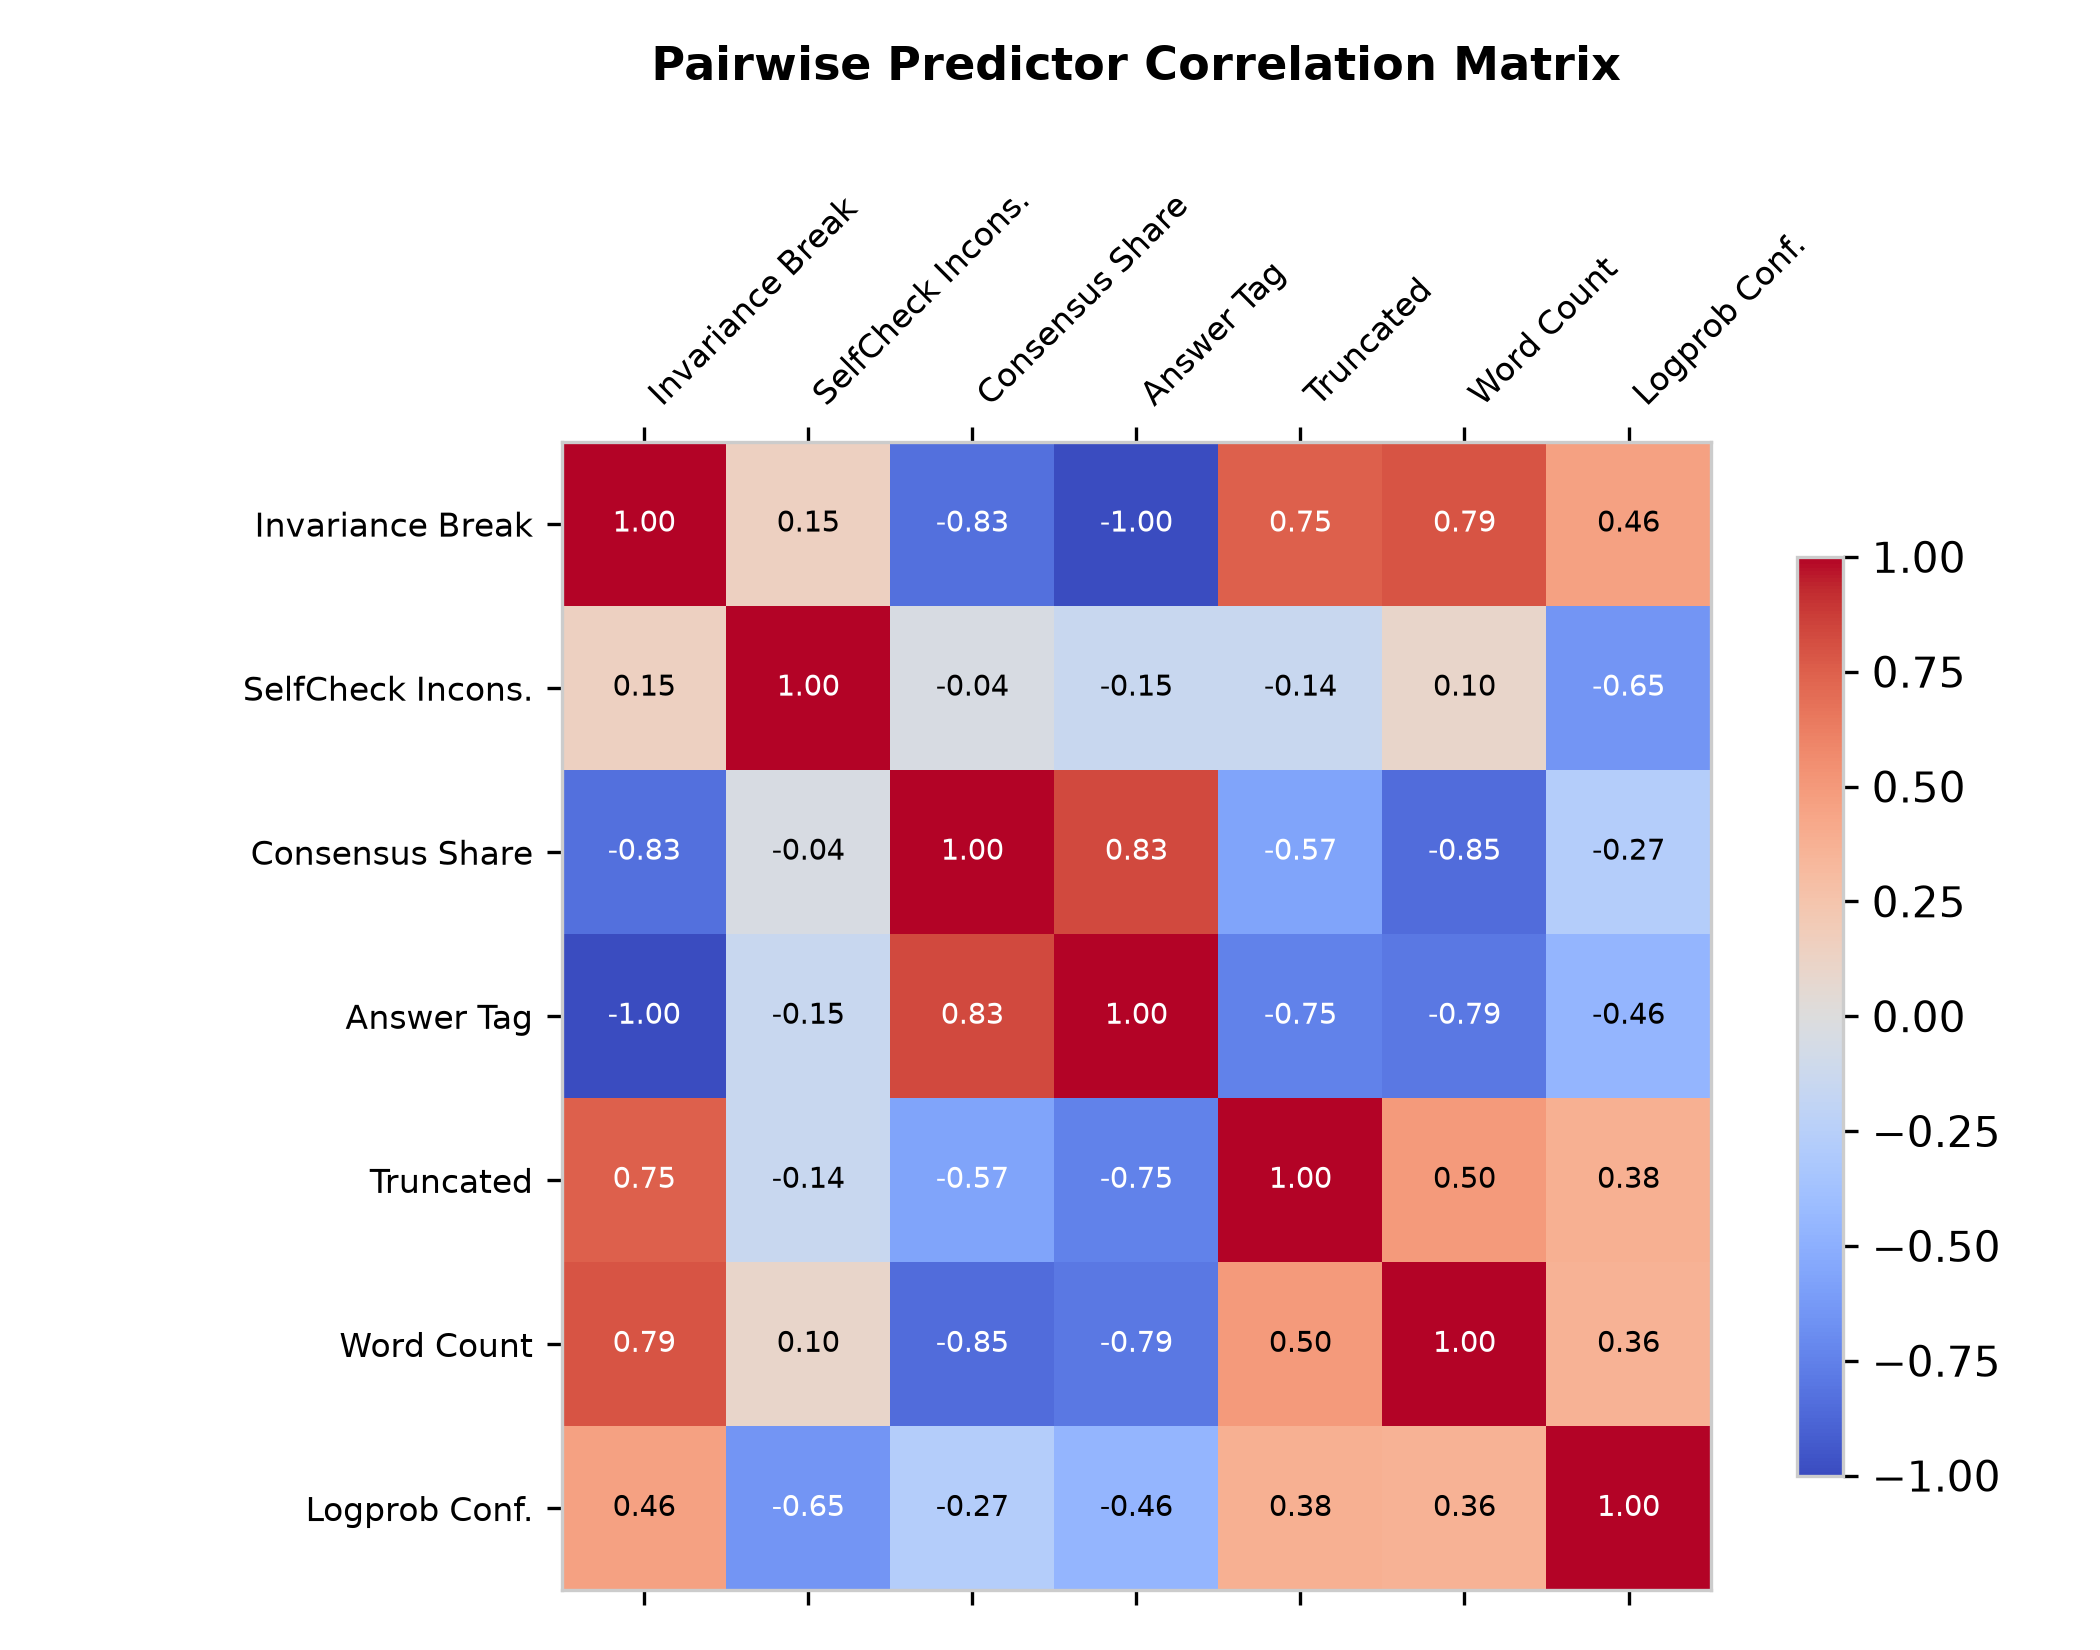

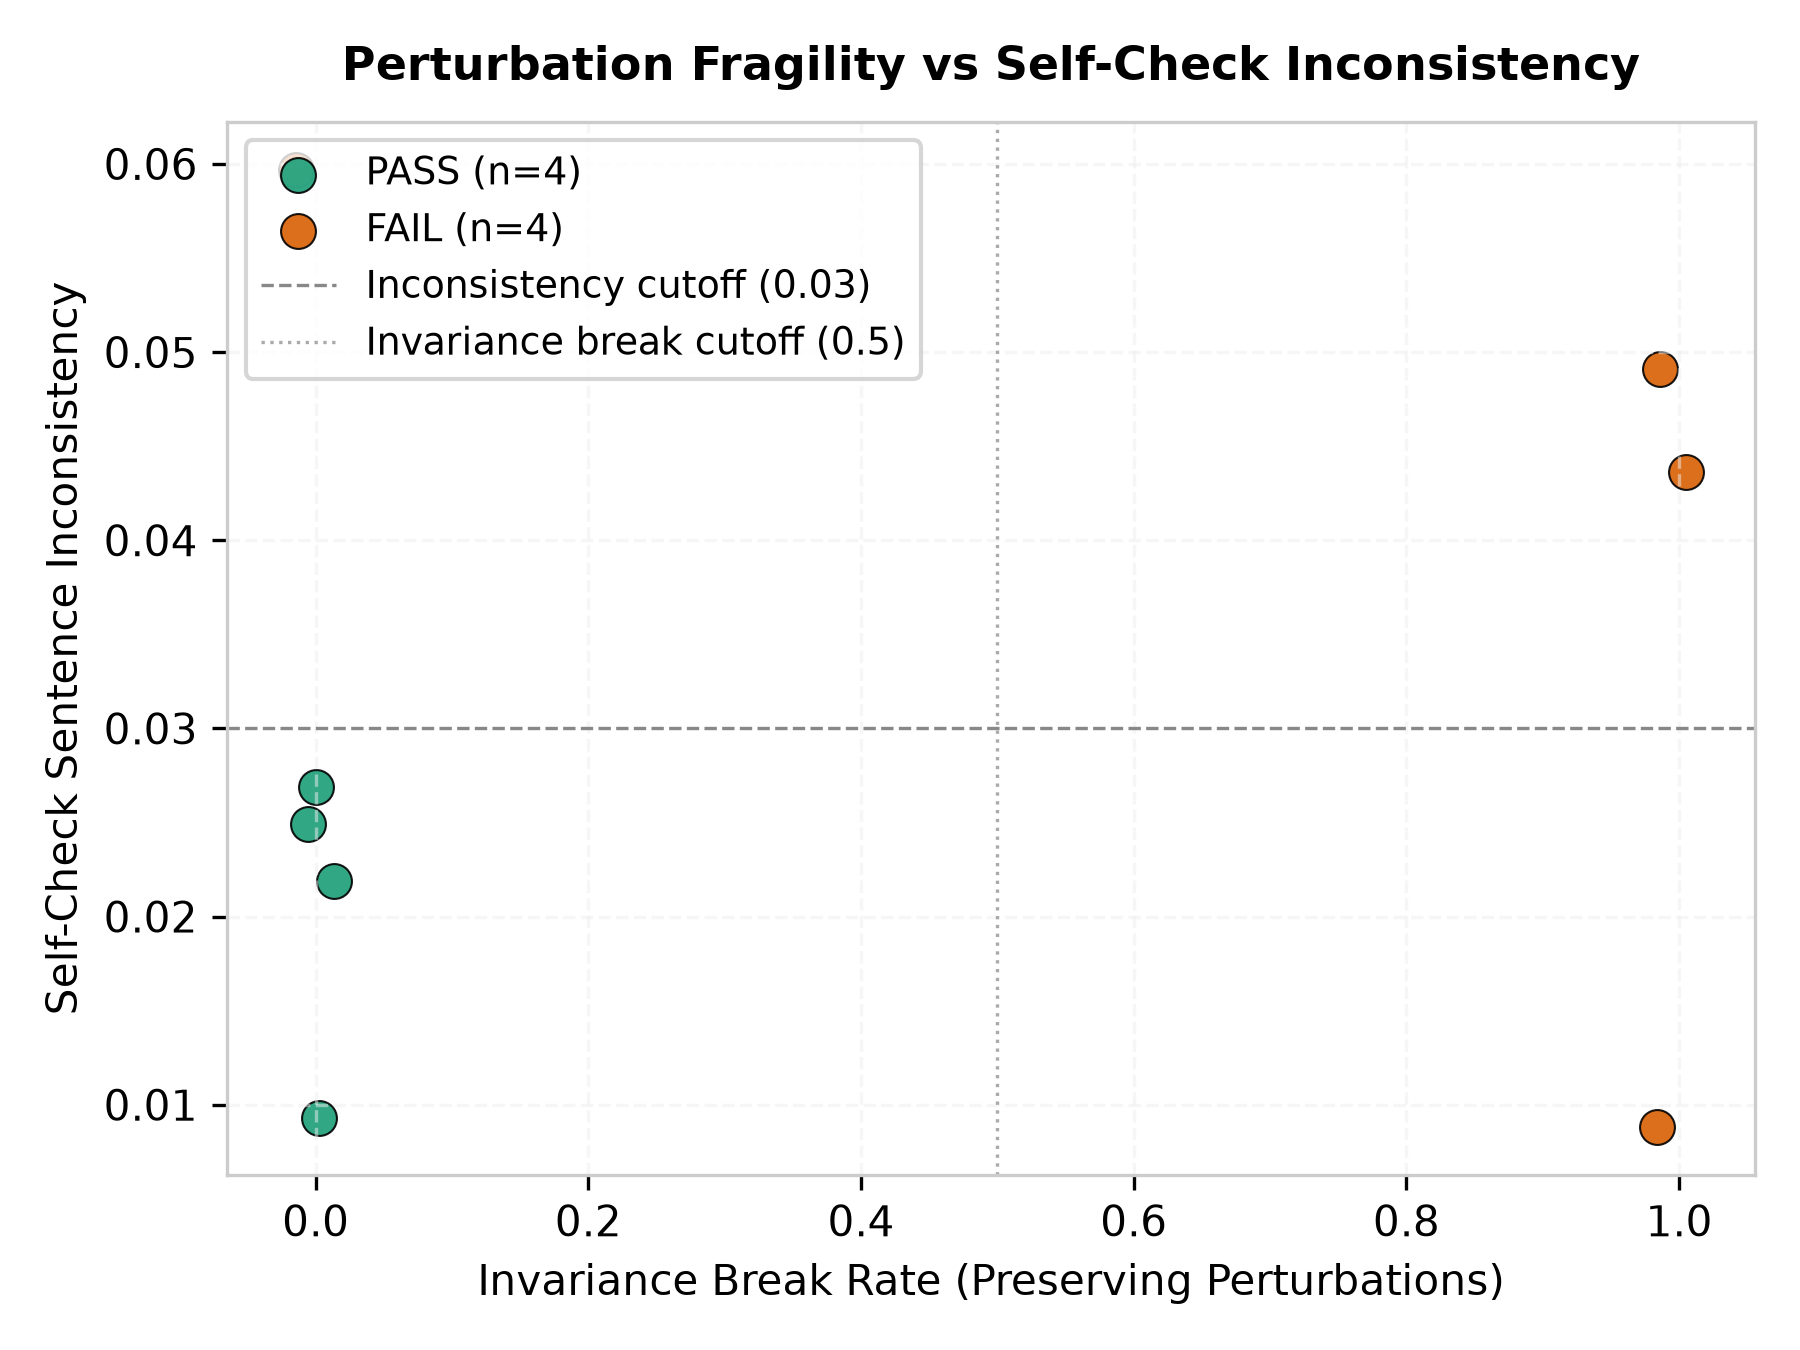

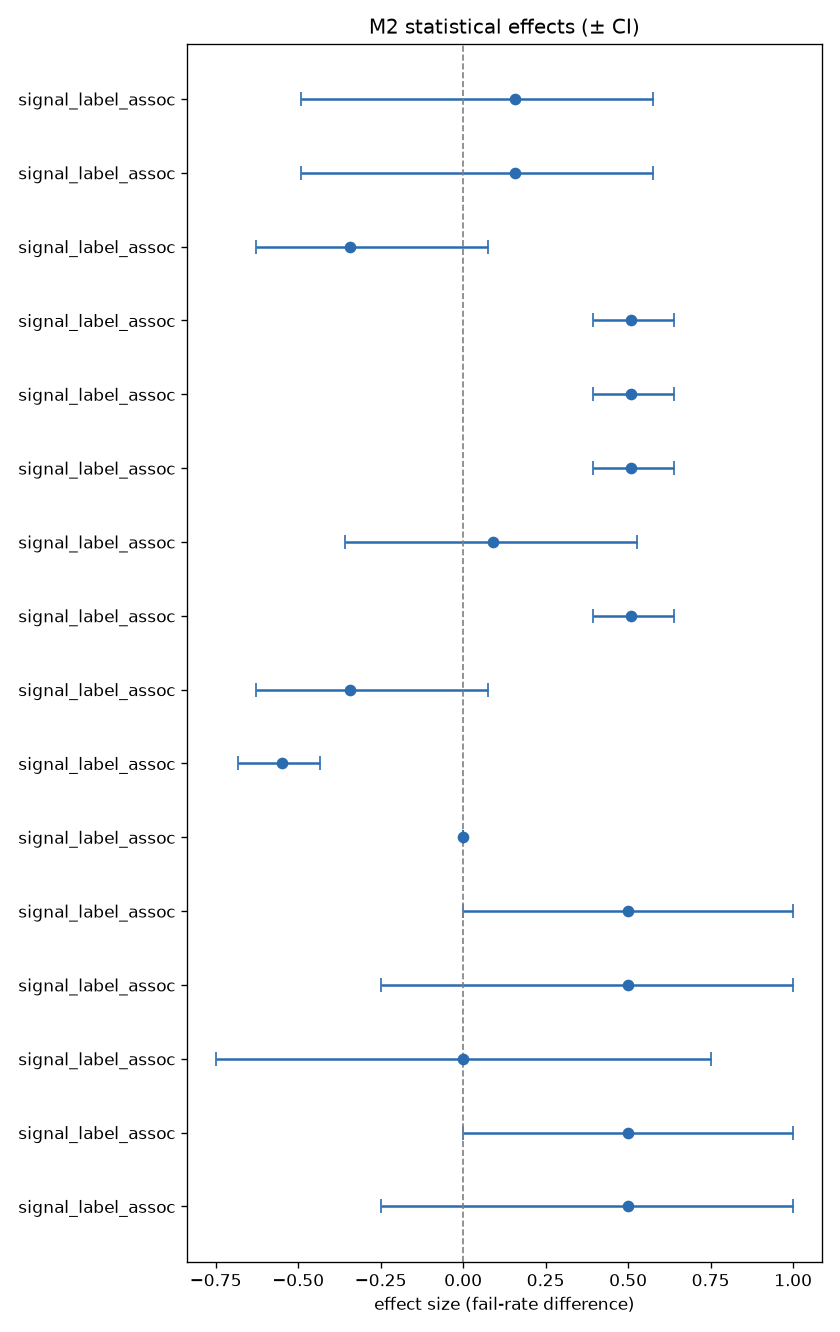

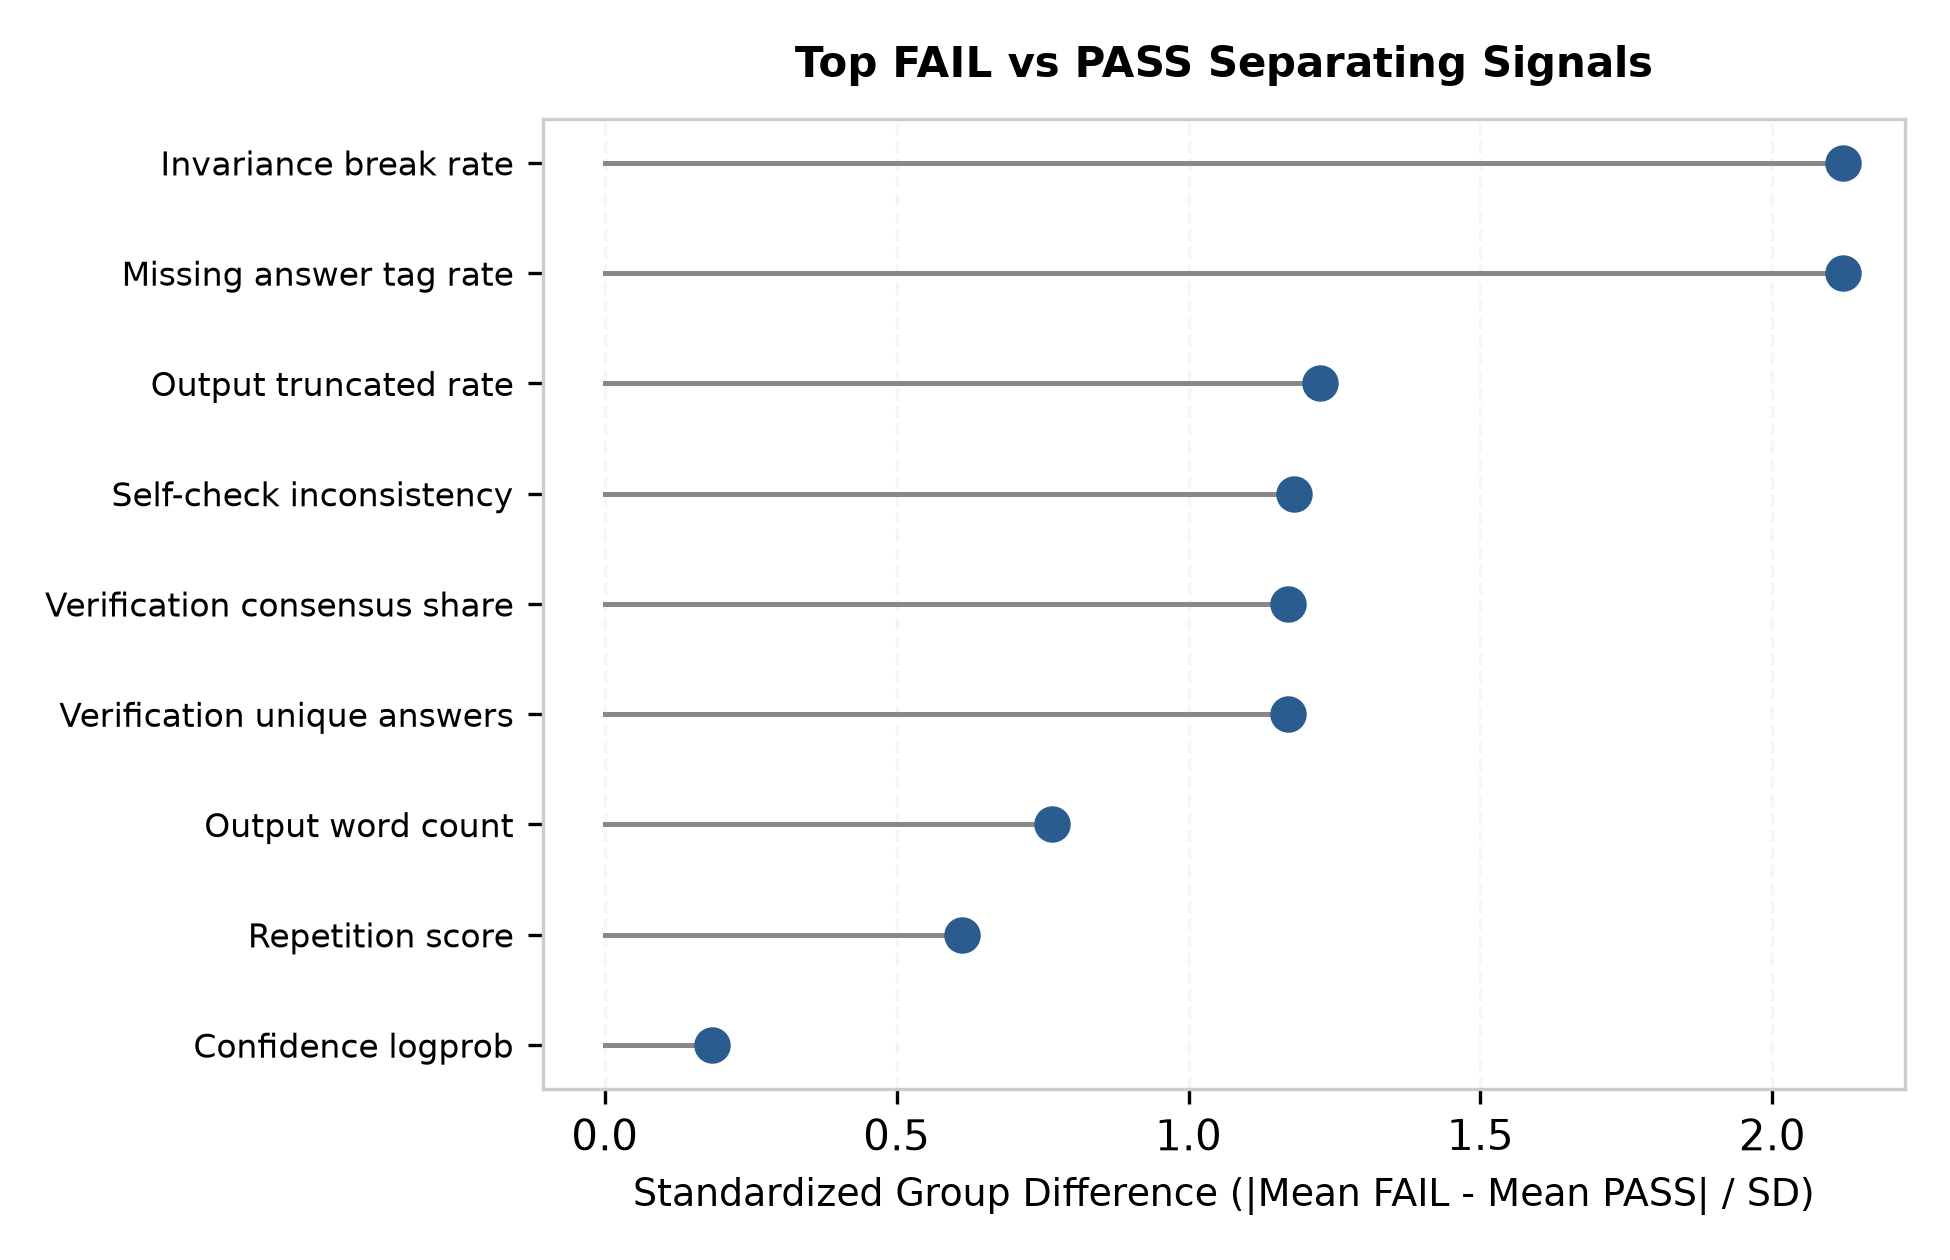

In [4]:
import json
import pandas as pd
from IPython.display import display, Markdown, Image, JSON

run_dir = Path(os.environ['EVALRX_DEMO_ROOT']) / 'runs/gemma-4-e2b/cruxeval_output.tpu_notebook'
read_json = lambda p: json.loads(p.read_text())
baseline = read_json(run_dir / 'baseline.json')
summary = read_json(run_dir / 'summary.json')
stages = {stage: read_json(run_dir / 'logs' / stage / 'log.json')
          for stage in ['M1', 'M2', 'M3', 'M4', 'M5']
          if (run_dir / 'logs' / stage / 'log.json').exists()}
fix = (stages.get('M5', {}).get('fix') or [{}])[-1]
attempts = fix.get('attempted', [])
print(f"Baseline: {baseline['n_pass']}/{baseline['n']} ({baseline['accuracy']:.1%})")
print(f"Verified hypotheses: {summary['n_verified']}")
print('Frozen candidate:', fix.get('selected_on_explore') or 'none')
if attempts:
    final = attempts[0]
    display(pd.DataFrame([{
        'split': 'CONFIRM', 'n': final['n_pairs'],
        'baseline_correct': final['n_baseline_correct'],
        'candidate_correct': final['n_candidate_correct'],
        'repaired_cases': final['n_fixed'], 'regressed_cases': final['n_broken'],
        'e_value': final['e_value'], 'required_e_value': final['e_threshold'],
        'verdict': final['verdict'], 'validated_fix': final['fixed'],
    }]))
    display(JSON(final['payload']))
    print('Accuracy repair validated.' if final['fixed'] else 'No statistically confirmed accuracy repair.')
else:
    print('No candidate selected for CONFIRM; no validated accuracy repair.')
if fix.get('selection_attempted'):
    display(Markdown('### EXPLORE candidates (selection only)'))
    display(pd.DataFrame(fix['selection_attempted']))
for image in sorted((run_dir / 'logs/M2/artifacts').glob('*.png')):
    display(Image(filename=str(image)))


## 5. Inspect every answer

These tables are generated from this run and saved in the notebook output, so a reader does not need separate result files.

In [5]:
manifest = read_json(Path(os.environ['EVALRX_DEMO_ROOT']) / 'data/cruxeval_output/manifest.json')
questions = {row['id']: row['prompt'] for row in manifest}
rows = [{**row, 'question': questions[row['id']]} for row in baseline['cases']]
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(pd.DataFrame(rows)[['id', 'question', 'expected', 'observed', 'label']])
    if attempts:
        before = {row['id']: row for row in baseline['cases']}
        display(pd.DataFrame([{
            'id': cid, 'expected': before[cid]['expected'],
            'baseline': before[cid]['observed'], 'candidate': answer,
            'repaired': cid in final['fixed_cases'], 'regressed': cid in final['broken_cases'],
        } for cid, answer in final['outputs'].items()]))


,id,question,expected,observed,label
0,cruxeval_output-0000,"Predict the output of this Python function for the given input.\n\ndef f(text, fill, size):\n if size < 0:\n size = -size\n if len(text) > size:\n return text[len(text) - size:]\n return text.rjust(size, fill)\n\nInput: 'no asw', 'j', 1\n\nGive only the output value on the last line as 'Answer: <value>'.\n\nSolve the problem. Put the final answer on its own last line as 'Answer: <answer>'.",'w',"Let's trace the execution of the function `f` with the given input:\n`text = 'no asw'`\n`fill = 'j'`\n`size = 1`\n\n1. **Check `if size < 0:`**:\n `size` is 1. $1 < 0$ is False. The code proceeds.\n\n2. **Check `if len(text) > size:`**:\n `len(text)` is `len('no asw')`, which is 6.\n `size` is 1.\n $6 > 1$ is True.\n\n3. **Execute the return statement inside the first `if` block**:\n `return text[len(text) - size:]`\n `len(text) - size` is $6 - 1 = 5$.\n The slice is `text[5:]`.\n `text` is 'n', 'o', ' ', 'a', 's', 'w'.\n Indices: 0, 1, 2, 3, 4, 5.\n `text[5:]` returns the substring starting from index 5 to the end, which is 'w'.\n\nWait, let's re-examine the input string and indices carefully:\n`text = 'n o a s w'` (Length 6)\nIndex: 0 1 2 3 4 5\nCharacter: n o a s w\n\n`text[5:]` is the character at index 5, which is 'w'.\n\nLet's re-read the input string: `'no asw'`\nn (0), o (1), space (2), a (3), s (4), w (5).\nLength is 6.\n\nIf `size = 1`, we return `text[6 - 1:]` which is `text[5:]`.\n`text[5]` is 'w'.\n\nLet's check the alternative path just in case the logic was misinterpreted, although the condition $6 > 1$ is true.\n\nIf the condition was false (e.g., if `text` was 'abc' and `size` was 5):\n`return text.rjust(size, fill)`\n`'abc'.rjust(5, 'j')` would return `'j abc'`.\n\nSince",fail
1,cruxeval_output-0001,"Predict the output of this Python function for the given input.\n\ndef f(list):\n for i in range(len(list) - 1, 0, -1):\n for j in range(i):\n if list[j] > list[j + 1]:\n list[j], list[j + 1] = list[j + 1], list[j]\n list.sort()\n return list\n\nInput: [63, 0, 1, 5, 9, 87, 0, 7, 25, 4]\n\nGive only the output value on the last line as 'Answer: <value>'.\n\nSolve the problem. Put the final answer on its own last line as 'Answer: <answer>'.","[0, 0, 1, 4, 5, 7, 9, 25, 63, 87]","The provided Python function `f(list)` attempts to sort a list using a nested loop structure that resembles a variation of Bubble Sort or Insertion Sort, but with an unusual modification: after a swap, it calls `list.sort()`, which sorts the entire list in ascending order.\n\nLet's trace the execution with the input list:\n`list = [63, 0, 1, 5, 9, 87, 0, 7, 25, 4]`\nThe length of the list is $N=10$.\n\nThe outer loop iterates `i` from `len(list) - 1` down to $1$ (exclusive of $0$), so $i$ goes from $9$ down to $1$.\n\nInside the outer loop, the inner loop iterates `j` from $0$ up to $i-1$.\n\n**Crucial Observation:** Inside the inner loop, if a swap occurs (`list[j] > list[j + 1]`), the list is immediately sorted using `list.sort()`.\n\nIf `list.sort()` is called, the list becomes sorted in ascending order.\n\nLet's trace the first iteration of the outer loop ($i=9$):\n`list = [63, 0, 1, 5, 9, 87, 0, 7, 25, 4]`\n\nThe inner loop runs for $j = 0$ to $8$.\n\nWhen $j=0$: `list[0]=63`, `list[1]=0`. $63 > 0$.\nSwap: `list` becomes `[0, 63, 1, 5, 9, 87, 0, 7, 25, 4]`.\n`list.sort()` is called.\n`list` becomes `[0, 0, 1, 4, 5, 7, 9, 25, 63, 87]`.\n\nNow, the rest of the inner loop iterations for $i=9$ will operate on this newly sorted list, but the structure of the outer loop suggests that the process continues for $i=8, 7, \dots, 1$.\n\nSince the list is sorted after the very first swap (when $i=9, j=0$), subsequent operations will",fail
2,cruxeval_output-0002,"Predict the output of this Python function for the given input.\n\ndef f(d):\n dCopy = d.copy()\n for key, value in dCopy.items():\n for i in range(len(value)):\n value[i] = value[i].upper()\n return dCopy\n\nInput: {'X': ['x', 'y']}\n\nGi

,id,expected,baseline,candidate,repaired,regressed
0,cruxeval_output-0003,"['9', '+', '+', '+']","Let's trace the execution of the function `f` with the input `students = ['r', '9']`.\n\n1. **`seatlist = students`**:\n `seatlist` becomes `['r', '9']`.\n\n2. **`seatlist.reverse()`**:\n `seatlist` becomes `['9', 'r']`.\n\n3. **`cnt = 0`**:\n Initialize `cnt` to 0.\n\n4. **`for cnt in range(len(seatlist))`**:\n `len(seatlist)` is 2. The loop will iterate for `cnt` in `range(2)`, so `cnt` will take values 0 and 1.\n\n **Iteration 1: `cnt = 0`**\n a. **`cnt += 2`**: `cnt` becomes $0 + 2 = 2$.\n b. **`seatlist[cnt - 1:cnt] = ['+']`**:\n The slice is `seatlist[2 - 1 : 2]`, which is `seatlist[1:2]`.\n `seatlist` is currently `['9', 'r']`.\n `seatlist[1:2]` refers to the element at index 1, which is `'r'`.\n Replacing this slice with `['+']`:\n `seatlist` becomes `['9', '+']`.\n\n **Iteration 2: `cnt = 1`**\n a. **`cnt += 2`**: `cnt` becomes $2 + 2 = 4$.\n b. **`seatlist[cnt - 1:cnt] = ['+']`**:\n The slice is `seatlist[4 - 1 : 4]`, which is `seatlist[3:4]`.\n `seatlist` is currently `['9', '+']`.\n Since the length of `seatlist` is 2, slicing up to index 4 (i.e., `seatlist[3:4]`) results in an empty slice if the start index is out of bounds or beyond the end, but Python slicing handles this gracefully. If the start index is $\ge$ length, the slice is empty.\n In this case, `seatlist[3:4]` is an empty slice.\n Replacing an empty","The function `f(students)` takes a list of strings as input and modifies it in place (or creates a new list based on the initial reference) and returns the modified list.\n\nInput: `students = ['r', '9']`\n\n**Step-by-step execution:**\n\n1. **`seatlist = students`**:\n `seatlist` now references the list `['r', '9']`.\n\n2. **`seatlist.reverse()`**:\n The list `seatlist` is reversed in place.\n `seatlist` becomes `['9', 'r']`.\n\n3. **`cnt = 0`**:\n Initialize the counter variable `cnt` to 0.\n\n4. **`for cnt in range(len(seatlist))`**:\n `len(seatlist)` is 2. The loop will iterate for `cnt` values 0 and 1 (based on the initial length, but the loop variable `cnt` will be reassigned in each iteration).\n\n **Iteration 1: `cnt` is 0 (from `range(2)`)**\n a. **`cnt += 2`**: `cnt` becomes $0 + 2 = 2$.\n b. **`seatlist[cnt - 1:cnt] = ['+']`**:\n The slice is `seatlist[2 - 1 : 2]`, which is `seatlist[1:2]`. This selects the element at index 1.\n `seatlist` is `['9', 'r']`.\n Setting `seatlist[1:2] = ['+']` replaces the element at index 1 with `'+'`.\n `seatlist` becomes `['9', '+']`.\n\n **Iteration 2: `cnt` is 1 (from `range(2)`)**\n a. **`cnt += 2`**: `cnt` becomes $2 + 2 = 4$.\n b. **`seatlist[cnt - 1:cnt] = ['+']`**:\n The slice is `seatlist[4 - 1 : 4]`, which is `seatlist[3:4]`.\n `seatlist` is currently `['9', '+']`. Since the length of `seatlist` is 2, slicing up to index 4 (exclusive) will only affect indices that exist or are out of bounds in a way that Python handles gracefully for assignment.\n For a slice `[start:end]`, if `end` is greater than the list length, it goes up to the end. If `start` is out of bounds, it starts at the end.\n Since `start=3` and `end=4`, and the list length is 2, this slice is effectively empty or invalid for assignment in this context if we strictly interpret it as replacing elements.\n Let's re-examine the list state: `seatlist = ['9', '+']`. Length is 2.\n `seatlist[3:4]` attempts to replace elements starting at index 3 up to (but not including) index 4. Since index 3 is out of bounds for assignment (it's beyond the current length), this operation effectively does nothing to the existing list structure in this specific case, or it might raise an error depending on the exact Python version/context if the slice indices are strictly interpreted for replacement. However, list slice assignment works by replacing the elements in that slice range. If the slice is entirely out of bounds, it might do nothing.\n In Python, `list[i:j] = iterable` can insert or replace elements. If $i 

## 6. Full agent and stage records

The saved records include generated code, analysis, hypotheses, candidate selection and confirmation. Save the executed notebook to keep these results together.

In [6]:
display(JSON({'baseline': baseline, 'summary': summary, 'stages': stages}))
for source in sorted(run_dir.rglob('*.py')):
    print('\n---', source.relative_to(run_dir), '---')
    print(source.read_text())


<IPython.core.display.JSON object>